# Linear SVM V1 - 거북목 판별 모델

V1 전처리 함수(`preprocessing_V1.extract_features`)를 사용하여 랜드마크 데이터에서 특성을 추출하고,
선형 SVM 모델로 거북목 여부를 분류합니다.

In [17]:
import json
import sys
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

sys.path.append('../../shared')
from preprocessing_V1 import extract_features

## 1. 데이터 로드

In [18]:
with open('../datasets/train_data_set_01.json', 'r') as f:
    train_raw = json.load(f)

with open('../datasets/test_data_set_baseline.json', 'r') as f:
    test1_raw = json.load(f)

with open('../datasets/test_data_set_angle_change.json', 'r') as f:
    test2_raw = json.load(f)

with open('../datasets/test_data_set_distance_change.json', 'r') as f:
    test3_raw = json.load(f)

train_samples = train_raw['samples'] if isinstance(train_raw, dict) else train_raw
test1_samples = test1_raw['samples'] if isinstance(test1_raw, dict) else test1_raw
test2_samples = test2_raw['samples'] if isinstance(test2_raw, dict) else test2_raw
test3_samples = test3_raw['samples'] if isinstance(test3_raw, dict) else test3_raw

print(f'Train samples: {len(train_samples)}')
print(f'Test1 samples (baseline): {len(test1_samples)}')
print(f'Test2 samples (카메라 각도 변경): {len(test2_samples)}')
print(f'Test3 samples (카메라 거리 변경): {len(test3_samples)}')

Train samples: 284
Test1 samples (baseline): 55
Test2 samples (카메라 각도 변경): 113
Test3 samples (카메라 거리 변경): 172


## 2. 전처리 (특성 추출)

In [19]:
def preprocess(samples):
    X, y = [], []
    for sample in samples:
        landmarks = {
            'nose': sample['nose'],
            'leftEar': sample['leftEar'],
            'rightEar': sample['rightEar'],
            'leftShoulder': sample['leftShoulder'],
            'rightShoulder': sample['rightShoulder'],
        }
        features = extract_features(landmarks)
        X.append(features)
        y.append(sample['label'])
    return np.array(X), np.array(y)

X_train_raw, y_train = preprocess(train_samples)
X_test1_raw, y_test1 = preprocess(test1_samples)
X_test2_raw, y_test2 = preprocess(test2_samples)
X_test3_raw, y_test3 = preprocess(test3_samples)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test1 = scaler.transform(X_test1_raw)
X_test2 = scaler.transform(X_test2_raw)
X_test3 = scaler.transform(X_test3_raw)

print(f'Train shape: {X_train.shape}')
print(f'Test1 shape: {X_test1.shape}')
print(f'Test2 shape: {X_test2.shape}')
print(f'Test3 shape: {X_test3.shape}')
print(f'Train label 분포: 0={np.sum(y_train==0)}, 1={np.sum(y_train==1)}')
print(f'Test1 label 분포: 0={np.sum(y_test1==0)}, 1={np.sum(y_test1==1)}')
print(f'Test2 label 분포: 0={np.sum(y_test2==0)}, 1={np.sum(y_test2==1)}')
print(f'Test3 label 분포: 0={np.sum(y_test3==0)}, 1={np.sum(y_test3==1)}')

Train shape: (284, 3)
Test1 shape: (55, 3)
Test2 shape: (113, 3)
Test3 shape: (172, 3)
Train label 분포: 0=140, 1=144
Test1 label 분포: 0=26, 1=29
Test2 label 분포: 0=55, 1=58
Test3 label 분포: 0=85, 1=87


## 3. 특성 분포 시각화

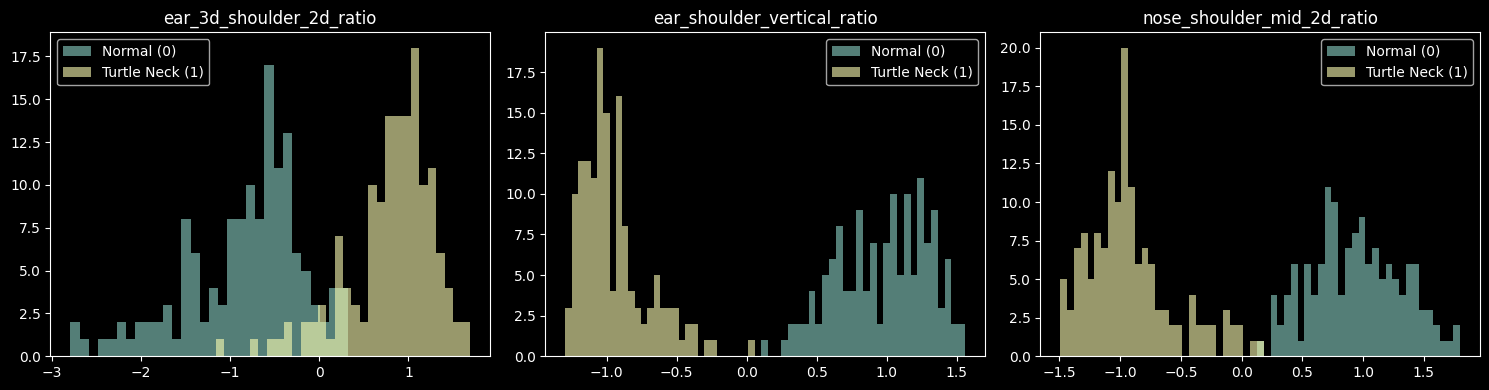

In [20]:
feature_names = ['ear_3d_shoulder_2d_ratio', 'ear_shoulder_vertical_ratio', 'nose_shoulder_mid_2d_ratio']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (ax, name) in enumerate(zip(axes, feature_names)):
    ax.hist(X_train[y_train == 0, i], bins=30, alpha=0.6, label='Normal (0)')
    ax.hist(X_train[y_train == 1, i], bins=30, alpha=0.6, label='Turtle Neck (1)')
    ax.set_title(name)
    ax.legend()
plt.tight_layout()
plt.show()

## 4. 선형 SVM 학습

In [21]:
model = SVC(kernel='linear', random_state=42)
model.fit(X_train, y_train)

print('학습 완료')

학습 완료


## 5. 평가

In [22]:
y_pred_train = model.predict(X_train)
y_pred_test1 = model.predict(X_test1)
y_pred_test2 = model.predict(X_test2)
y_pred_test3 = model.predict(X_test3)

print(f'Train Accuracy:                      {accuracy_score(y_train, y_pred_train):.4f}')
print(f'Test1 Accuracy (baseline):           {accuracy_score(y_test1, y_pred_test1):.4f}')
print(f'Test2 Accuracy (카메라 각도 변경):   {accuracy_score(y_test2, y_pred_test2):.4f}')
print(f'Test3 Accuracy (카메라 거리 변경):   {accuracy_score(y_test3, y_pred_test3):.4f}')

Train Accuracy:                      1.0000
Test1 Accuracy (baseline):           1.0000
Test2 Accuracy (카메라 각도 변경):   0.9204
Test3 Accuracy (카메라 거리 변경):   0.9302


## 6. Confusion Matrix

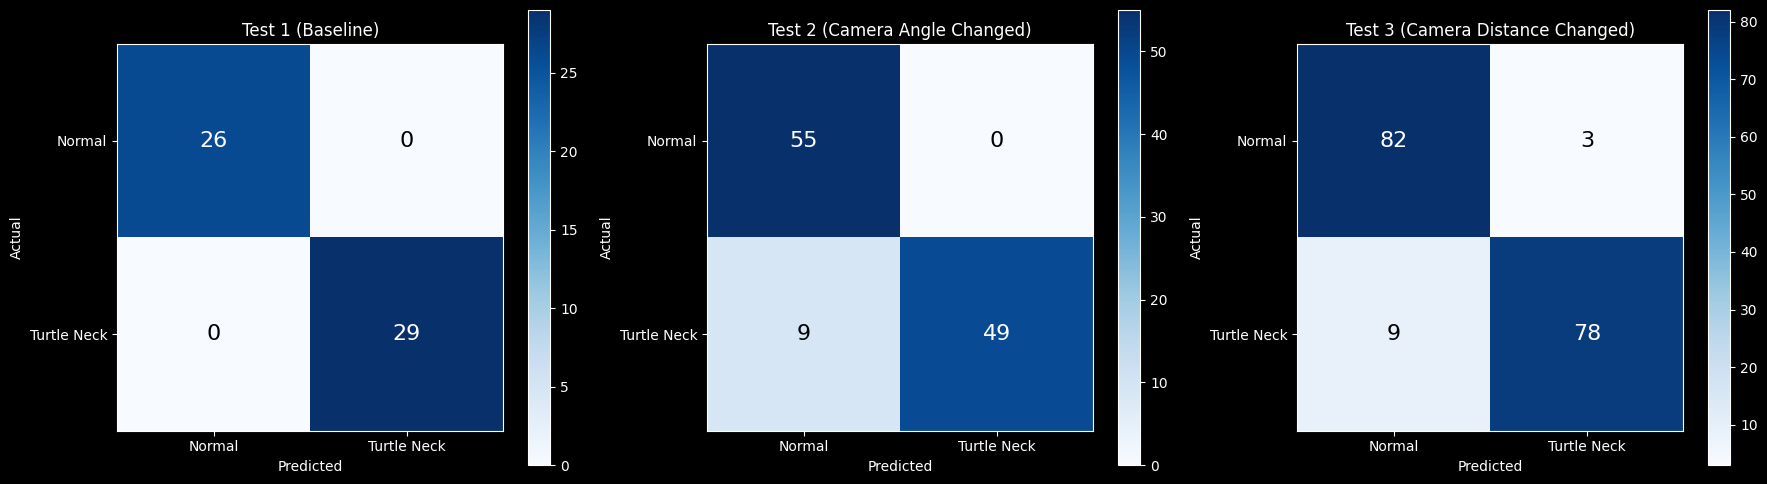

In [23]:
cm1 = confusion_matrix(y_test1, y_pred_test1)
cm2 = confusion_matrix(y_test2, y_pred_test2)
cm3 = confusion_matrix(y_test3, y_pred_test3)
labels = ['Normal', 'Turtle Neck']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in [(ax1, cm1, 'Test 1 (Baseline)'), (ax2, cm2, 'Test 2 (Camera Angle Changed)'), (ax3, cm3, 'Test 3 (Camera Distance Changed)')]:
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=16)

plt.tight_layout()
plt.show()

## 7. 특성 중요도

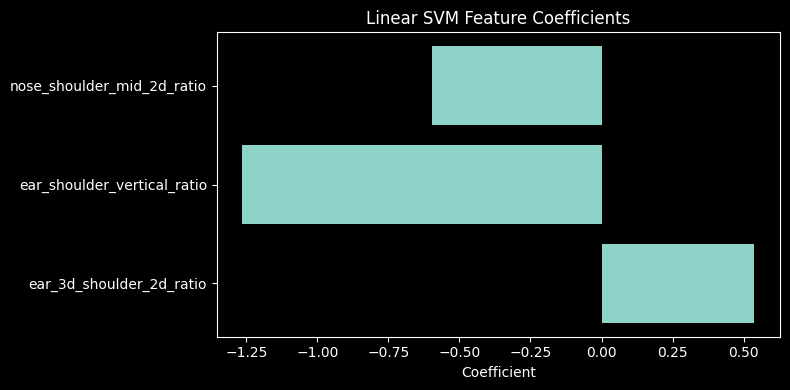

In [24]:
coefficients = model.coef_[0]

plt.figure(figsize=(8, 4))
plt.barh(feature_names, coefficients)
plt.xlabel('Coefficient')
plt.title('Linear SVM Feature Coefficients')
plt.tight_layout()
plt.show()